In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion,Pipeline
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import VotingClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression

# Models
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# MilesStone 1

In [2]:
trainData = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
testData = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

In [3]:
print(trainData.shape)
trainData.head()

(198000, 15)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
print(testData.shape)
testData.head()

(102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


In [5]:
trainData.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [6]:
trainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
def anyMissing(df):
    print("Missing values in trainData:")
    for col in df.columns:
        missingCount = df[col].isna().sum()
        if missingCount > 0:
            print(f"{col}: {missingCount}")
            
    print("\nQuestion marks in trainData:")
    for col in df.columns:  
        if(df[col] == '?').any():  
            print(f"{col}: {(df[col] == '?').sum()}")

In [8]:
anyMissing(trainData)

Missing values in trainData:
race: 145423
religion: 145423
gender: 145423
comment: 1

Question marks in trainData:
comment: 1


In [9]:
anyMissing(testData)

Missing values in trainData:
race: 75269
religion: 75269
gender: 75269

Question marks in trainData:


In [10]:
trainData["created_date"] = pd.to_datetime(trainData["created_date"])
trainData["label"].unique()

array([2, 0, 1, 3])

In [11]:
trainData['label'].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [12]:
catFeat = ['race', 'gender', 'religion','disability']
numericCols = ['post_id','emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2']

# Preprocessing

In [13]:
TrainData = trainData.copy()
TestData = testData.copy()

In [14]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text) 
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

In [15]:
def preprocess_data(df):
    df = df.copy()
    
    df['comment'] = df['comment'].fillna('?').replace('?', '')
    df['char_count'] = df['comment'].apply(len)
    df['word_count'] = df['comment'].apply(lambda x: len(x.split()))
    df['upper_ratio'] = df['comment'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    
    df['comment'] = df['comment'].apply(clean_text)
    
    df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
    df['hour'] = df['created_date'].dt.hour.fillna(-1)
    df['dayofweek'] = df['created_date'].dt.dayofweek.fillna(-1)

    df['net_votes'] = df['upvote'] - df['downvote']
    df['total_emoticons'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    
    cat_cols = ['race', 'religion', 'gender', 'disability']
    for col in cat_cols:
        df[col] = df[col].astype(str).replace('nan', 'missing').fillna('missing')
        
    return df

In [16]:
TrainData = preprocess_data(TrainData)
TestData = preprocess_data(TestData)

In [17]:
print(f"TrainData shape: {TrainData.shape}")
print(f"testData shape: {TestData.shape}")

TrainData shape: (198000, 22)
testData shape: (102000, 21)


In [18]:
anyMissing(TrainData)
anyMissing(TestData)

Missing values in trainData:

Question marks in trainData:
Missing values in trainData:

Question marks in trainData:


In [19]:
# min_count = TrainData['label'].value_counts().min()

# TrainData = (
#     TrainData.groupby('label')
#     .sample(n=min_count, random_state=42)
#     .reset_index(drop=True)
# )

In [20]:
XTrainData = TrainData.drop(['label', 'created_date', 'post_id'], axis=1, errors='ignore')
YTrainData = TrainData['label']
XTestData = TestData.drop(['created_date', 'post_id'], axis=1, errors='ignore')

text_features = FeatureUnion([
    ('word_tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=10000, stop_words='english')),
    ('char_tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=10000)),
]) # type: ignore

text_pipeline = Pipeline([
    ('tfidf_union', text_features),
    ('svd', TruncatedSVD(n_components=1000, random_state=42))
])

numeric_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 
                'char_count', 'word_count', 'upper_ratio', 'hour', 'dayofweek', 'net_votes', 'total_emoticons']
cat_cols = ['race', 'religion', 'gender', 'disability']

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, 'comment'),
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [21]:
smote = SMOTE(random_state=42)

In [22]:
XTrain,XVal,YTrain,YVal = train_test_split(XTrainData, YTrainData, test_size = 0.2, random_state = 42, stratify=YTrainData)

n,d = XTrain.shape
print(f"Number of training examples: {n}")
print(f"Number of features: {d}")

Number of training examples: 158400
Number of features: 19


In [23]:
XTrain.shape, XVal.shape,XTestData.shape

((158400, 19), (39600, 19), (102000, 19))

# EDA

In [24]:
UniqueTrainPostIds = trainData["post_id"].unique()
UniqueTestPostIds = testData["post_id"].unique()
print(f"Unique post ids in TrainData: {len(UniqueTrainPostIds)}")
print(f"Unique post ids in testData: {len(UniqueTestPostIds)}")
overlapPostIds = set(UniqueTrainPostIds) & set(UniqueTestPostIds)
print(f"Overlapping post ids between TrainData and testData: {len(overlapPostIds)}")

Unique post ids in TrainData: 52
Unique post ids in testData: 45
Overlapping post ids between TrainData and testData: 45


In [25]:
def plotColvsComments(TrainData, numericCols):
    fig, axes = plt.subplots(len(numericCols)//2 + len(numericCols)%2, 2, figsize=(25, 35))
    axes = axes.flatten()

    for i, col in enumerate(numericCols):
        post_counts = TrainData[col].value_counts().sort_values(ascending=False)

        axes[i].bar(post_counts.index.astype(str), post_counts.values)  # type: ignore
        axes[i].tick_params(axis='x', labelrotation=90)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Total Comments")
        axes[i].set_title(f"{col} vs Total Comments")

    plt.tight_layout()
    plt.show()

In [26]:
def plotFeatureVsLabel(TrainData, numericCols,w,h):

    features = [c for c in numericCols if c != 'label']
    n_rows = len(features)
    fig, axes = plt.subplots(n_rows*2, 2, figsize=(w, h))

    for i, col in enumerate(features):
        for j in range(4):
            ax = axes[i*2 + j//2, j%2]  # type: ignore
            subset = TrainData[TrainData['label'] == j]
            counts = subset[col].value_counts().sort_values(ascending=False)
            ax.bar(counts.index.astype(str), counts.values)
            ax.set_title(f"{col} | label={j}")
            ax.set_xlabel(col)
            ax.set_ylabel("count")
            ax.tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

    import numpy as np

In [27]:
def plotLabelvsPostID(TrainData, UniqueTrainPostIds):
    fig, axes = plt.subplots(13, 4, figsize=(20, 13 * 4))
    axes = axes.flatten()
    UniqueTrainPostIds = TrainData["post_id"].unique()
    for i, post_id_value in enumerate(UniqueTrainPostIds):
        thread_df = TrainData[TrainData["post_id"] == post_id_value]
        label_counts = thread_df["label"].value_counts().sort_index()
        label_percentages = (label_counts / label_counts.sum()) * 100
        
        axes[i].bar(label_percentages.index.astype(str), label_percentages.values)
        axes[i].set_title(f"Post {post_id_value}")
        axes[i].set_xlabel("Label")
        axes[i].set_ylabel("Percentage (%)")
        axes[i].set_ylim(0, 100)
    
    
    plt.tight_layout()
    plt.show()

In [28]:
# plotFeatureVsLabel(trainData, numericCols, 25, 100)

In [29]:
# plotColvsComments(trainData, numericCols)

In [30]:
from sklearn.feature_selection import f_classif
def performANOVA(TrainData, numericCols):
    X = TrainData[numericCols].drop(columns=['label'])
    y = TrainData['label']

    F_scores, p_values = f_classif(X, y)

    anova_results = pd.DataFrame({
        'feature': X.columns,
        'F_score': F_scores.round(7),
        'p_value': p_values.round(7)
    }).sort_values(by='F_score', ascending=False)

    print(anova_results)

In [31]:
performANOVA(TrainData, numeric_cols+['label'])

            feature      F_score   p_value
6              if_2  4168.082320  0.000000
7        char_count   471.063468  0.000000
8        word_count   414.758571  0.000000
5              if_1   330.204329  0.000000
4          downvote   214.922505  0.000000
3            upvote   203.115197  0.000000
12        net_votes    78.332304  0.000000
2        emoticon_3    68.106846  0.000000
1        emoticon_2    51.073338  0.000000
9       upper_ratio    35.634183  0.000000
13  total_emoticons    12.368299  0.000000
0        emoticon_1     1.852899  0.135174
10             hour     0.984400  0.398899
11        dayofweek     0.493447  0.686815


<Axes: >

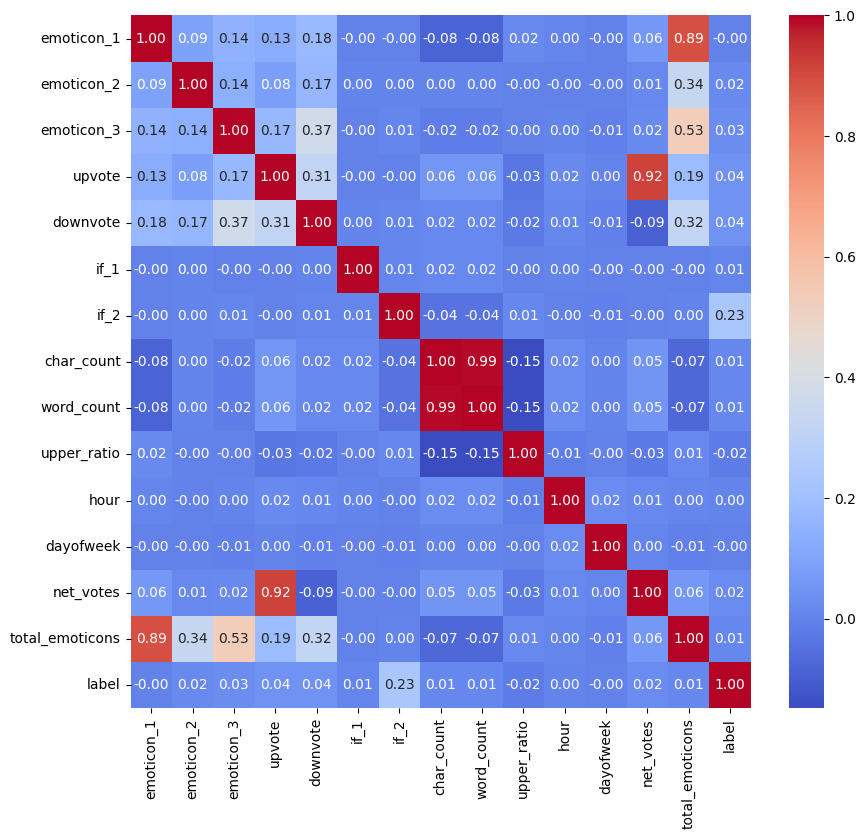

In [32]:
corr_matrix = TrainData[numeric_cols+['label']].corr()
plt.figure(figsize=(10, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

# Models

In [33]:
# weights = {
#     0: 1,
#     2: 1,  
#     1: 1, 
#     3: 1   
# }
# # weights = {
# #     0: 1.0,
# #     2: 1.5,  
# #     1: 8.0, 
# #     3: 25.0   
# # }

In [34]:
class MultiModel:
    def __init__(self, models: dict,ensemble=False):
        self.models = models
        self.fitted_models = {}
        self.predictions = {}
        self.ensemble = ensemble
    def fit(self, X, y, models:list):
        for name in models:
            model = self.models[name]
            print(f"Training {name}...")
            model.fit(X, y)
            self.fitted_models[name] = model
    def predict(self, X,models:list):
        for name in models:
            model = self.fitted_models[name]
            self.predictions[name] = model.predict(X)
        return self.predictions

    def score(self, y,avg):
        self.scores = {}
        for name, _ in self.fitted_models.items():
            self.scores[name] = {
                'accuracy': round(accuracy_score(y, self.predictions[name]), 4),
                'f1_score': round(f1_score(y, self.predictions[name], average=avg), 4), # type: ignore
                'recall': round(recall_score(y, self.predictions[name], average=avg), 4), # type: ignore
                'precision': round(precision_score(y, self.predictions[name], average=avg), 4) # type: ignore
            }
        return self.scores

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier

Models = MultiModel({
    "lgb":ImbPipeline(steps=[
            ('preprocessor', preprocessor), 
            ('smote', smote), 
            ('classifier', lgb.LGBMClassifier(objective='multiclass',n_estimators=400,learning_rate=0.05,random_state=42,n_jobs=-1))
        ]),
    "lr":ImbPipeline(steps=[
            ('preprocessor', preprocessor), 
            ('smote', smote), 
            ('classifier', LogisticRegression(max_iter=1000,C=1.5,solver='saga',random_state=42))
        ]),
    "xgb":ImbPipeline(steps=[
            ('preprocessor', preprocessor), 
            ('smote', smote), 
            ('classifier', xgb.XGBClassifier(objective='multi:softmax',eval_metric='mlogloss',n_estimators=300,
                                             learning_rate=0.05,max_depth=6,random_state=42,n_jobs=-1))
        ])
})

In [36]:
# Models.fit(XTrain, YTrain, models=["lr"])

In [37]:
Models.fit(XTrainData, YTrainData, models=["lgb"])

Training lgb...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 7.991738 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263902
[LightGBM] [Info] Number of data points in the train set: 456692, number of used features: 1038
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


In [38]:
# Models.fit(XTrain, YTrain, models=["xgb"])

In [39]:
Preds = Models.predict(XVal,models=["lgb"])
scores = Models.score(YVal,avg='macro')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [40]:
scores

{'lgb': {'accuracy': 0.9233,
  'f1_score': 0.8661,
  'recall': 0.8914,
  'precision': 0.8446}}

# Ensemble Classifier

In [41]:
# voting_clf = VotingClassifier(estimators=list(Models.fitted_models.items()), voting='hard',weights=[1,1,1,1])

# voting_clf.fit(XTrain_reduced, YTrain)

In [42]:
# yValPred_voting = voting_clf.predict(XVal_reduced)
# f1pred_voting = f1_score(YVal, yValPred_voting, average='macro')
# acc_voting = accuracy_score(YVal, yValPred_voting)
# print(f"F1 Score on Validation Set (Voting Classifier): {f1pred_voting:.4f}")
# print(f"Accuracy on Validation Set (Voting Classifier): {acc_voting:.4f}")

# Submission

In [43]:
predictions = Models.predict(XTestData,models=["lgb"])["lgb"]

submission = pd.DataFrame({
    "ID": range(1,len(predictions)+1),
    "label": predictions
})

submission.to_csv("submission.csv", index=False)
submission.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
5,6,0
6,7,1
7,8,0
8,9,0
9,10,2
